In [ ]:
#Setup and data preparation

In [ ]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import ipywidgets as widgets
from ipywidgets import interact, Dropdown, IntSlider, FloatSlider
from IPython.display import display

# Styling
sns.set(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (12, 6)

# Load dataset
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/data/Superstore.csv', encoding='latin1')

# Quick audit
print("Shape:", df.shape)
print(df.columns.tolist())
print(df.isnull().sum())
df.info()

# Clean duplicates
df = df.drop_duplicates()

# Date types
for col in ['Order Date', 'Ship Date']:
    if col in df.columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

# Basic feature engineering
df['Order Year'] = df['Order Date'].dt.year
df['Order Month'] = df['Order Date'].dt.month
df['Order Month-Year'] = df['Order Date'].dt.to_period('M')
df['Profit Margin'] = np.where(df['Sales']>0, (df['Profit']/df['Sales'])*100, np.nan)
df['Ship Days'] = (df['Ship Date'] - df['Order Date']).dt.days

# Sanity checks
print(df[['Sales','Profit','Discount','Quantity','Profit Margin','Ship Days']].describe())

Shape: (9994, 21)
['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode', 'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State', 'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category', 'Product Name', 'Sales', 'Quantity', 'Discount', 'Profit']
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 no

In [ ]:
#Core KPIs and executive snapshot

In [ ]:
# Aggregate KPIs
total_sales = df['Sales'].sum()
total_profit = df['Profit'].sum()
overall_margin = (total_profit/total_sales)*100
orders = df['Order ID'].nunique() if 'Order ID' in df.columns else df.shape[0]

kpi = {
    'Total revenue': f"${total_sales:,.0f}",
    'Total profit': f"${total_profit:,.0f}",
    'Overall profit margin': f"{overall_margin:.1f}%",
    'Orders': f"{orders:,}"
}
kpi


{'Total revenue': '$2,297,201',
 'Total profit': '$286,397',
 'Overall profit margin': '12.5%',
 'Orders': '5,009'}

In [ ]:
#Time-series diagnostics

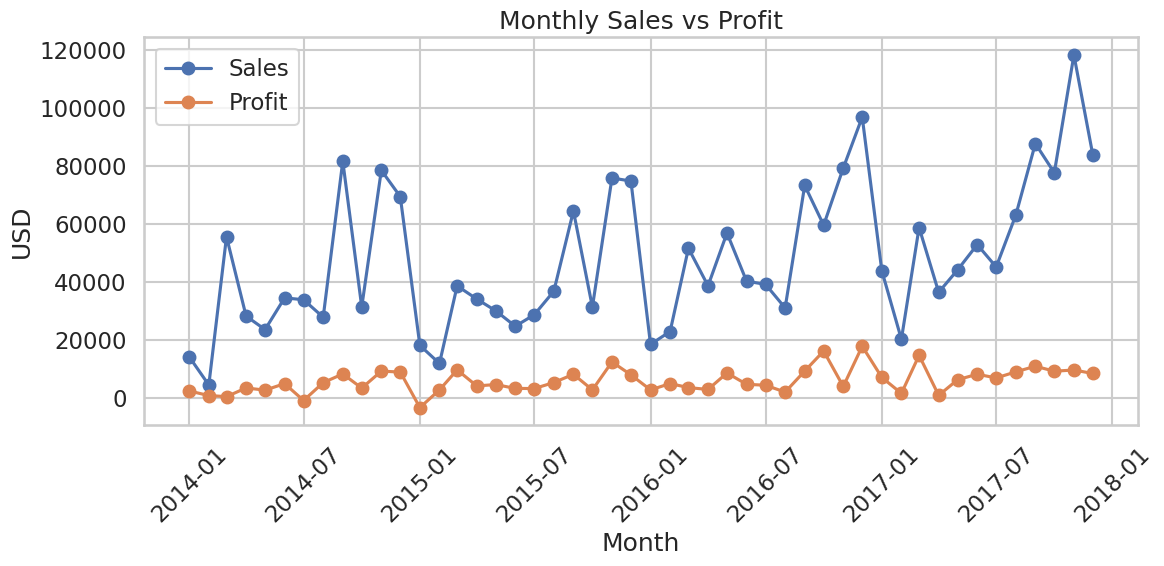

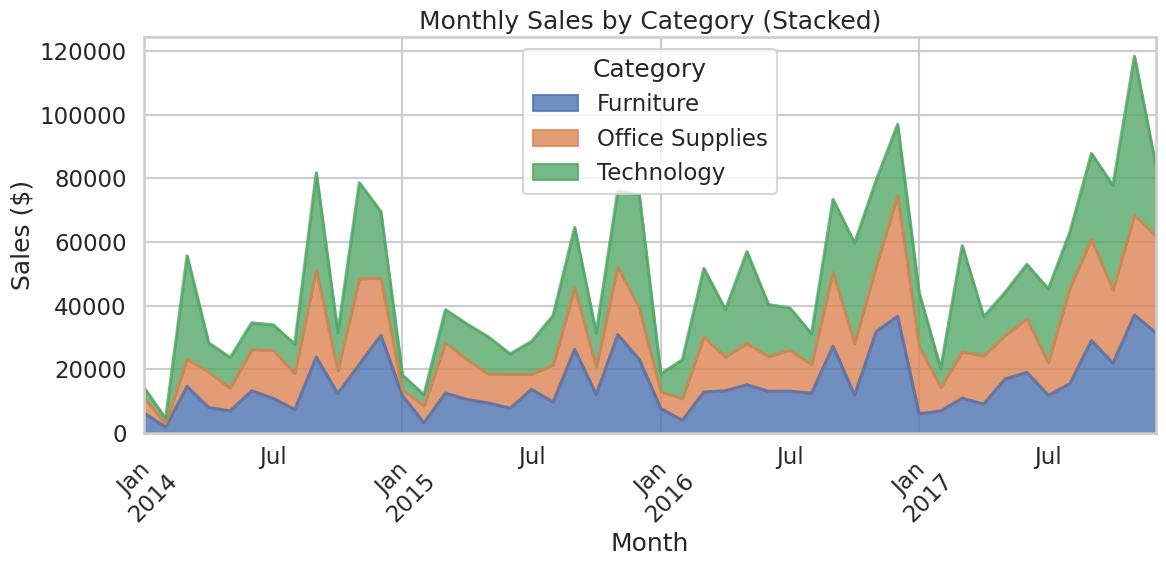

In [ ]:
# Monthly sales and profit
ts = df.groupby('Order Month-Year')[['Sales','Profit']].sum().reset_index()
ts['Date'] = ts['Order Month-Year'].dt.to_timestamp()

fig, ax = plt.subplots()
ax.plot(ts['Date'], ts['Sales'], label='Sales', marker='o')
ax.plot(ts['Date'], ts['Profit'], label='Profit', marker='o')
ax.set_title('Monthly Sales vs Profit')
ax.set_xlabel('Month'); ax.set_ylabel('USD'); ax.legend(); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

# Category contribution over time (stacked area)
cat_month = df.groupby(['Order Month-Year','Category'])['Sales'].sum().reset_index()
pivot_cat = cat_month.pivot(index='Order Month-Year', columns='Category', values='Sales').fillna(0)
pivot_cat.index = pivot_cat.index.to_timestamp()

pivot_cat.plot(kind='area', stacked=True, alpha=0.8)
plt.title('Monthly Sales by Category (Stacked)'); plt.xlabel('Month'); plt.ylabel('Sales ($)')
plt.xticks(rotation=45); plt.tight_layout(); plt.show()


In [ ]:
#Geographic analysis


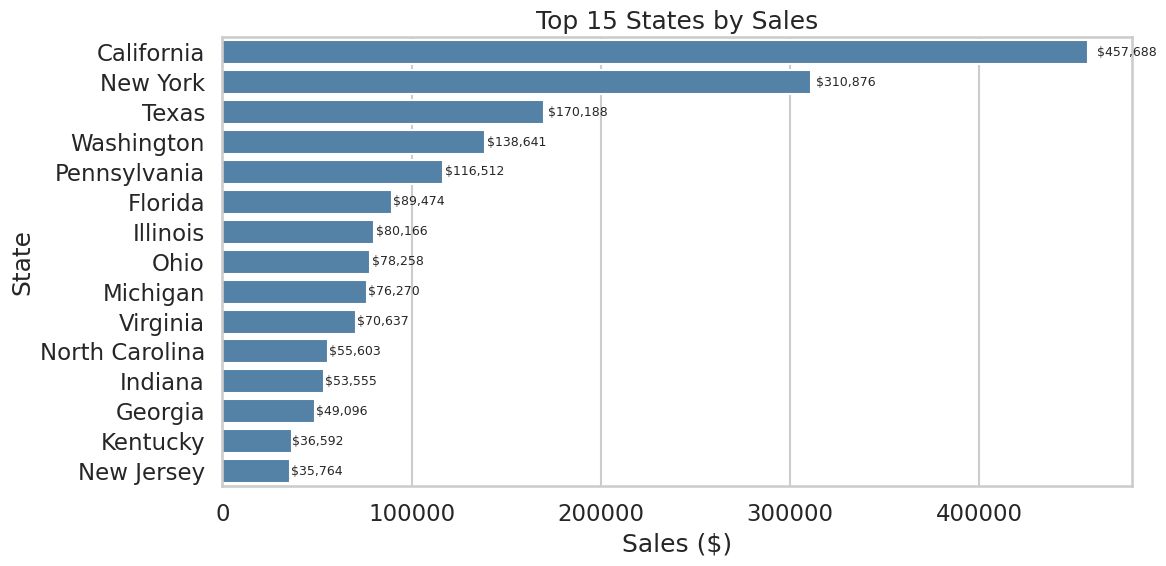

Top 5 states concentration: 52.0% of revenue


In [ ]:
# State performance
state_sales = df.groupby('State')['Sales'].sum().sort_values(ascending=False)
state_profit = df.groupby('State')['Profit'].sum().reindex(state_sales.index)

fig, ax = plt.subplots()
sns.barplot(x=state_sales.values[:15], y=state_sales.index[:15], color='steelblue', ax=ax)
ax.set_title('Top 15 States by Sales'); ax.set_xlabel('Sales ($)'); ax.set_ylabel('State')
for i, v in enumerate(state_sales.values[:15]): ax.text(v*1.01, i, f"${v:,.0f}", va='center', fontsize=9)
plt.tight_layout(); plt.show()

# Concentration metric
top5_share = state_sales.iloc[:5].sum() / state_sales.sum() * 100
print(f"Top 5 states concentration: {top5_share:.1f}% of revenue")


In [ ]:
#Discount strategy diagnostics

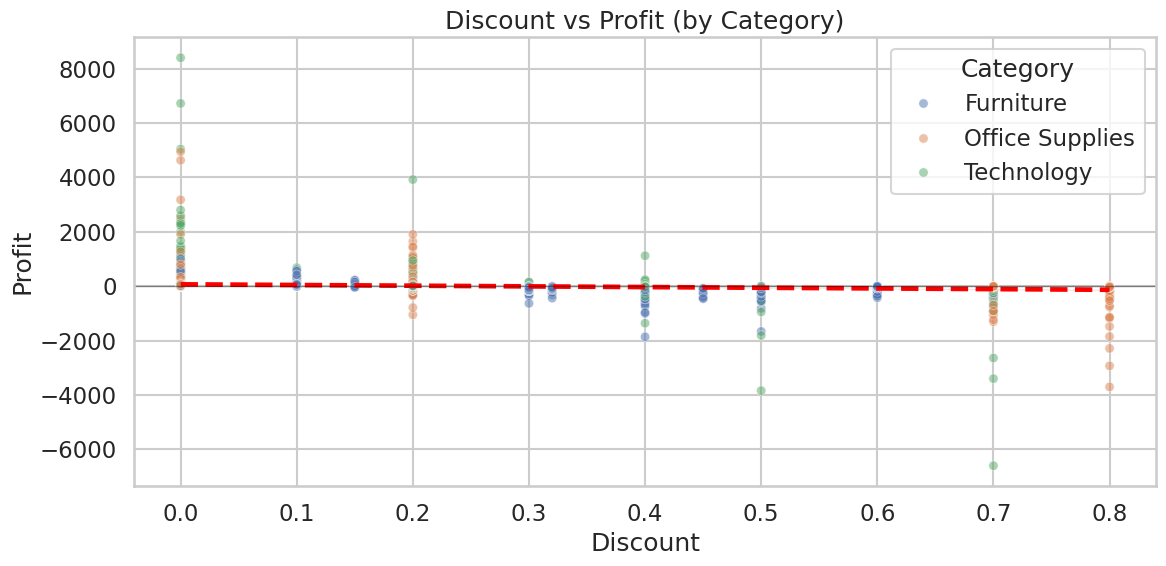

/tmp/ipython-input-4074451004.py:11: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  bucket = df.groupby('Disc Bucket').apply(lambda x: pd.Series({
/tmp/ipython-input-4074451004.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  bucket = df.groupby('Disc Bucket').apply(lambda x: pd.Series({


,Disc Bucket,Count,Loss rate %,Avg margin %
0,0–10%,4892.0,0.081766,33.661783
1,10–20%,3709.0,13.992990,17.483863
2,20–30%,227.0,91.629956,-11.548143
3,>30%,1166.0,97.770154,-91.473346


In [ ]:
# Scatter with trendline
plt.figure()
sns.scatterplot(data=df, x='Discount', y='Profit', hue='Category', alpha=0.5, s=45)
sns.regplot(data=df, x='Discount', y='Profit', scatter=False, color='red', line_kws={'linestyle':'--'})
plt.title('Discount vs Profit (by Category)')
plt.axhline(0, color='black', linewidth=1, alpha=0.4)
plt.tight_layout(); plt.show()

# Loss rate by discount bucket
df['Disc Bucket'] = pd.cut(df['Discount'], bins=[-0.01,0.1,0.2,0.3,1.0], labels=['0–10%','10–20%','20–30%','>30%'])
bucket = df.groupby('Disc Bucket').apply(lambda x: pd.Series({
    'Count': len(x),
    'Loss rate %': (x['Profit']<0).mean()*100,
    'Avg margin %': x['Profit Margin'].mean()
})).reset_index()
bucket


In [ ]:
#Category and time filters

In [ ]:
categories = ['All'] + sorted(df['Category'].dropna().unique().tolist())
months = sorted(df['Order Month-Year'].dropna().unique().tolist())

def plot_category_month(cat='All', start=None, end=None):
    d = df.copy()
    if start and end:
        d = d[(d['Order Month-Year']>=start) & (d['Order Month-Year']<=end)]
    if cat != 'All':
        d = d[d['Category']==cat]
    series = d.groupby('Order Month-Year')['Sales'].sum()
    plt.figure()
    plt.plot(series.index.to_timestamp(), series.values, marker='o')
    plt.title(f"Monthly Sales {'('+cat+')' if cat!='All' else ''}")
    plt.xlabel('Month'); plt.ylabel('Sales ($)'); plt.xticks(rotation=45); plt.tight_layout(); plt.show()

interact(
    plot_category_month,
    cat=Dropdown(options=categories, value='All', description='Category:'),
    start=Dropdown(options=[None]+months, value=None, description='Start:'),
    end=Dropdown(options=[None]+months, value=None, description='End:')
);


interactive(children=(Dropdown(description='Category:', options=('All', 'Furniture', 'Office Supplies', 'Techn…

In [ ]:
#Top-N states and discount threshold

In [ ]:
def plot_top_states(n=10):
    top = state_sales.iloc[:n].sort_values()
    plt.figure(figsize=(12, max(6, n*0.4)))
    sns.barplot(x=top.values, y=top.index, orient='h', color='teal')
    plt.title(f'Top {n} States by Sales'); plt.xlabel('Sales ($)'); plt.ylabel('State')
    plt.tight_layout(); plt.show()

interact(plot_top_states, n=IntSlider(min=5, max=25, value=10, description='Top N'));

def discount_impact(threshold=0.20):
    high = df[df['Discount'] >= threshold]
    rate = (high['Profit']<0).mean()*100
    avg = high['Profit'].mean()
    print(f"Threshold ≥ {threshold:.0%}: Loss rate {rate:.1f}%, Avg profit ${avg:,.2f}")

interact(discount_impact, threshold=FloatSlider(min=0.0, max=0.6, step=0.05, value=0.20, description='Disc ≥'));


interactive(children=(IntSlider(value=10, description='Top N', max=25, min=5), Output()), _dom_classes=('widge…

interactive(children=(FloatSlider(value=0.2, description='Disc ≥', max=0.6, step=0.05), Output()), _dom_classe…

In [ ]:
#Most profitable products

/tmp/ipython-input-2173793770.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=top_products.values, y=top_products.index, palette='viridis', orient='h')


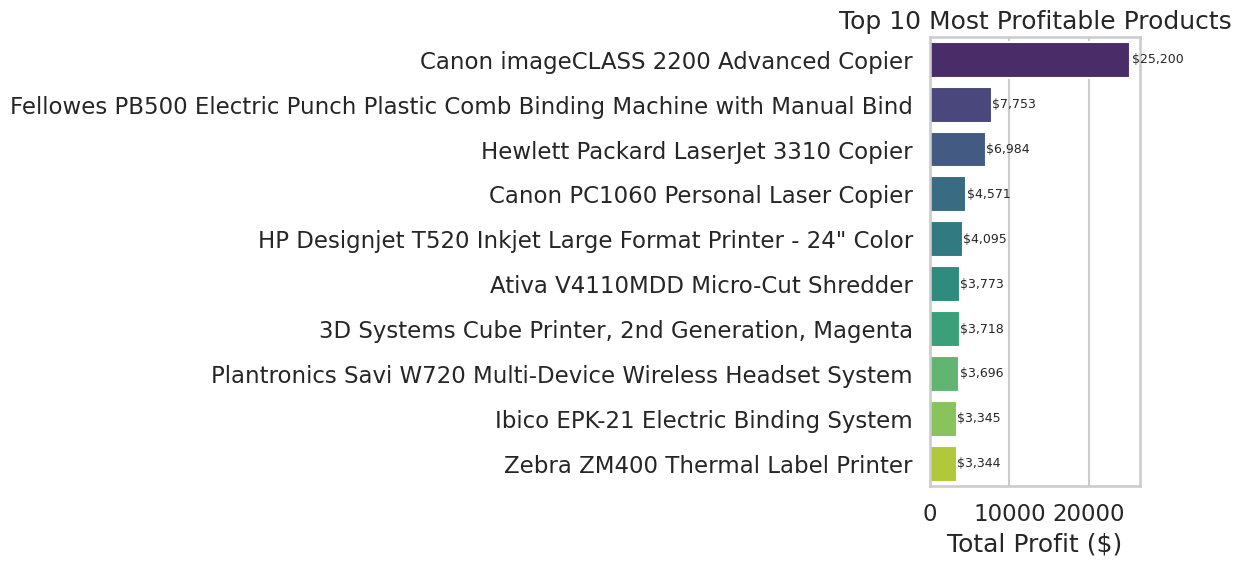

In [ ]:
top_products = df.groupby('Product Name')['Profit'].sum().sort_values(ascending=False).head(10)
ax = sns.barplot(x=top_products.values, y=top_products.index, palette='viridis', orient='h')
plt.title('Top 10 Most Profitable Products'); plt.xlabel('Total Profit ($)'); plt.ylabel('')
for i, v in enumerate(top_products.values):
    ax.text(v*1.01, i, f"${v:,.0f}", va='center', fontsize=9)
plt.tight_layout(); plt.show()


In [ ]:
#Category margin distribution

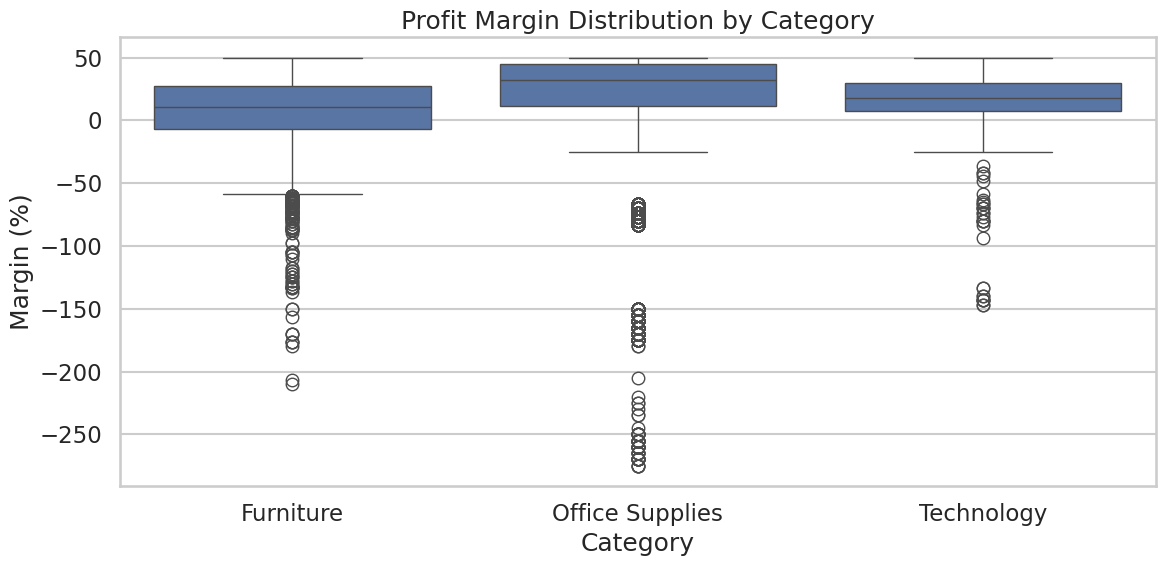

In [ ]:
plt.figure()
sns.boxplot(data=df, x='Category', y='Profit Margin')
plt.title('Profit Margin Distribution by Category'); plt.ylabel('Margin (%)')
plt.tight_layout(); plt.show()


In [ ]:
#Executive summary and recommendations

In [ ]:
print("=== Executive summary ===")
print(f"Revenue: ${total_sales:,.0f}, Profit: ${total_profit:,.0f}, Margin: {overall_margin:.1f}%")
print(f"Top 5 states concentration: {top5_share:.1f}% of revenue")
high_disc_loss = (df[df['Discount']>=0.20]['Profit']<0).mean()*100
print(f"Discount risk: {high_disc_loss:.1f}% of orders at ≥20% discount are loss-making")

# Tailored findings
lead_cat = df.groupby('Category')['Profit'].sum().sort_values(ascending=False).index[0]
weak_cat = df.groupby('Category')['Profit Margin'].mean().sort_values().index[0]
print(f"Leader category (profit): {lead_cat}")
print(f"Lowest avg margin category: {weak_cat}")


=== Executive summary ===
Revenue: $2,297,201, Profit: $286,397, Margin: 12.5%
Top 5 states concentration: 52.0% of revenue
Discount risk: 36.6% of orders at ≥20% discount are loss-making
Leader category (profit): Technology
Lowest avg margin category: Furniture
